<a href="https://colab.research.google.com/github/irynebbie17-cyber/Stock-prices-data.set-csv/blob/main/Stock_Prices_Data_Set_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
file_path = ('/content/2) Stock Prices Data Set.csv')
df = pd.read_csv(file_path, sep=None, engine='python', on_bad_lines='skip')
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
for column in ['open', 'high', 'low', 'close', 'volume']:
    if column in df.columns:
        df[column] = df[column].ffill()

print(df.isnull().sum())
df.head()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497472 non-null  float64
 3   high    497472 non-null  float64
 4   low     497472 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [ ]:
print('\nData Types:')
print(df.dtypes)


Data Types:
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [ ]:
print(df.columns.tolist())

['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


In [ ]:
df.columns = [col.capitalize()for col in df.columns]
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df.columns.tolist())
df.head()

['Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']


,Symbol,Date,Open,High,Low,Close,Volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,497472,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,2016-01-06 17:16:00.439984896,86.351835,87.131986,85.551898,86.369082,4.253611e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.350000,64.980000,2.084896e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.470449,102.311361,100.570269,101.472407,8.232139e+06


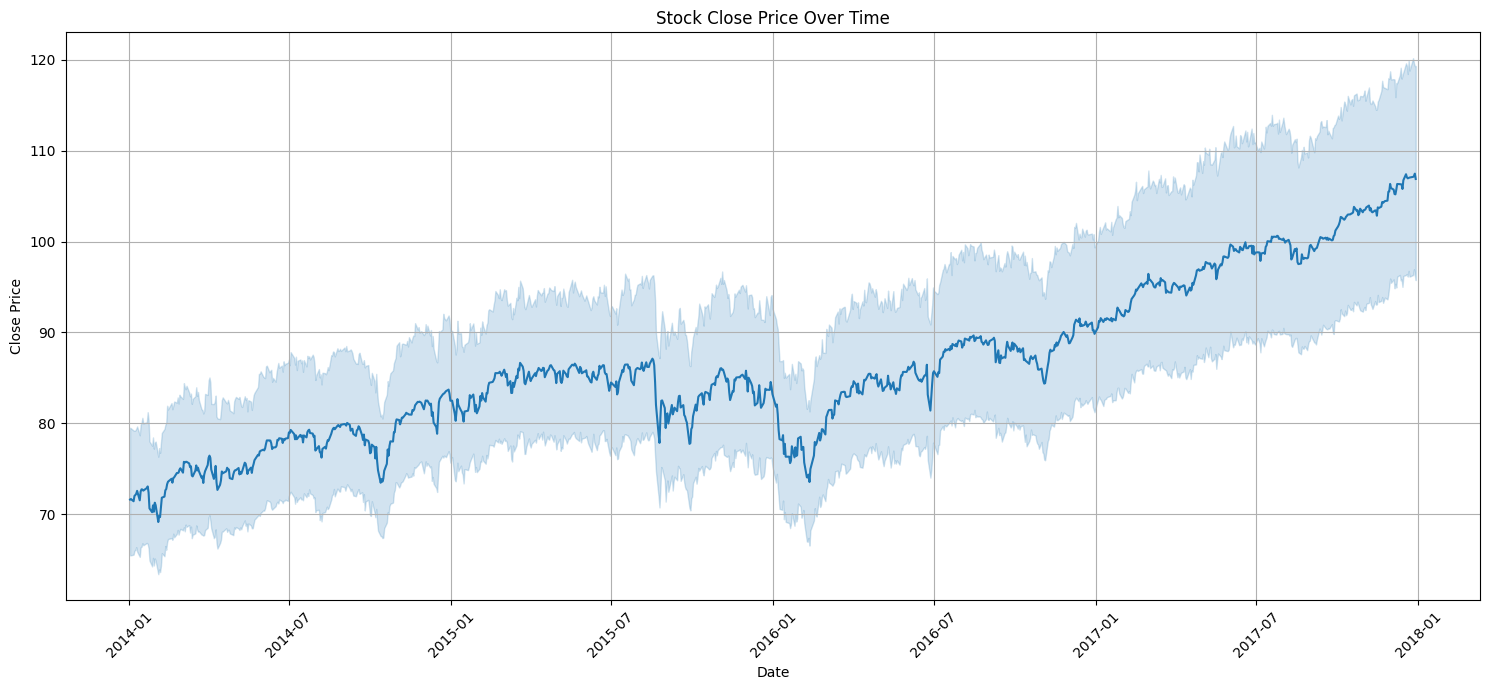

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close', data=df)
plt.title('Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stock_close_price_over_time.png')
plt.show()

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print('Correlation Matrix:')
print(correlation_matrix)

Correlation Matrix:
            Open      High       Low     Close    Volume
Open    1.000000  0.999937  0.999924  0.999852 -0.148721
High    0.999937  1.000000  0.999905  0.999917 -0.148341
Low     0.999924  0.999905  1.000000  0.999921 -0.149281
Close   0.999852  0.999917  0.999921  1.000000 -0.148839
Volume -0.148721 -0.148341 -0.149281 -0.148839  1.000000


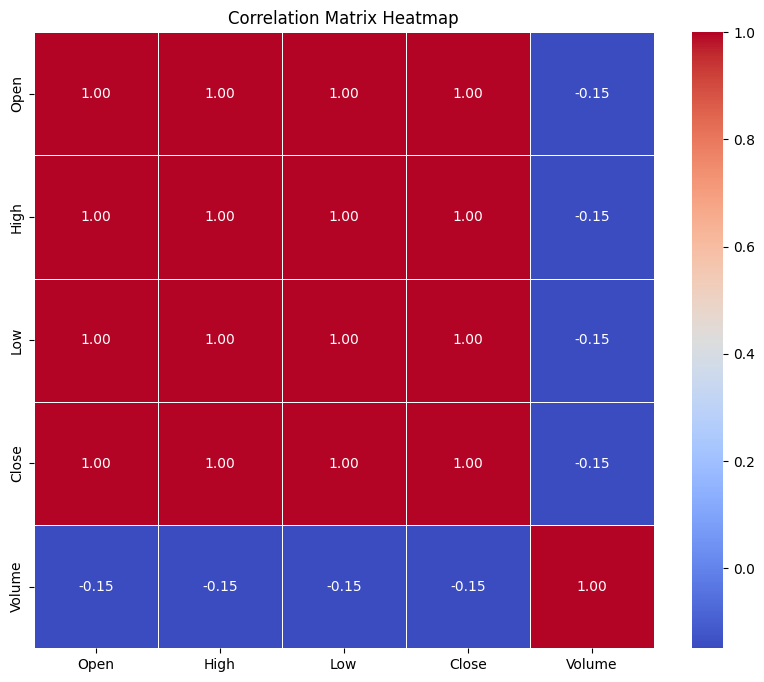

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.savefig('correlation_matrix_heatmap.png')
plt.show()

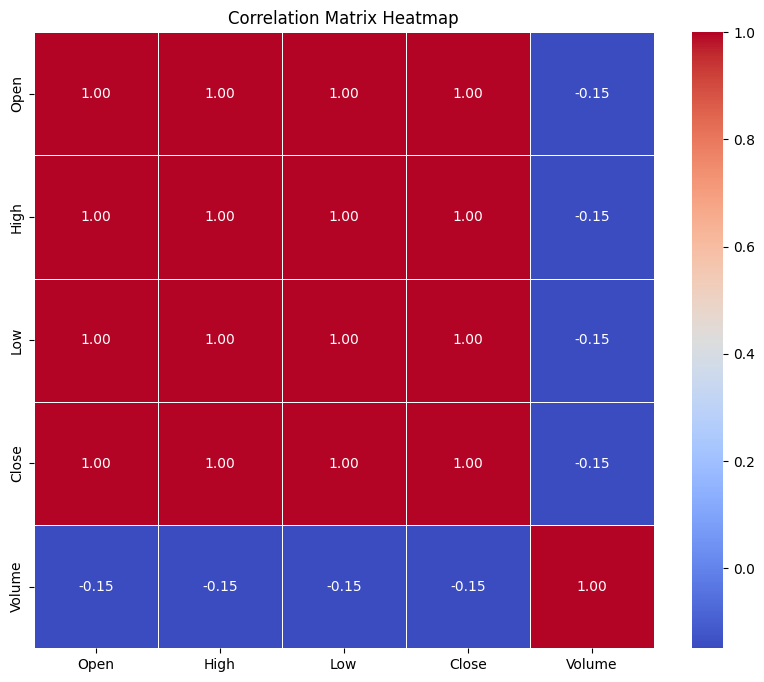

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print('Correlation Matrix:')
print(correlation_matrix)


Correlation Matrix:
            Open      High       Low     Close    Volume
Open    1.000000  0.999937  0.999924  0.999852 -0.148721
High    0.999937  1.000000  0.999905  0.999917 -0.148341
Low     0.999924  0.999905  1.000000  0.999921 -0.149281
Close   0.999852  0.999917  0.999921  1.000000 -0.148839
Volume -0.148721 -0.148341 -0.149281 -0.148839  1.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
x = df[['Open']]
y = df[['Close']]
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print('Data split successfully')

Data split successfully


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared (R2): {r2:.2f}')
print('Model training and prediction complete.')

Mean Absolute Error (MAE): 0.77
R-squared (R2): 1.00
Model training and prediction complete.


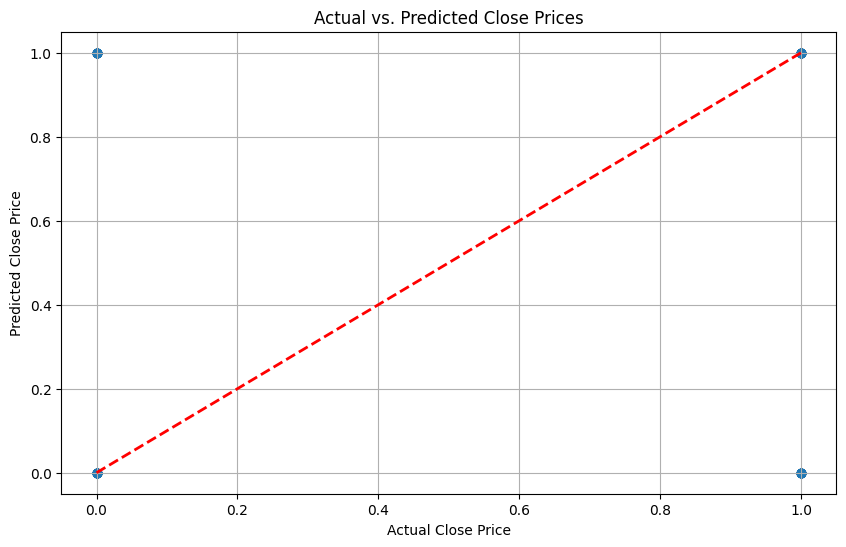

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs. Predicted Close Prices')
plt.grid(True)
plt.savefig('actual_vs_predicted_close_prices.png')
plt.show()

In [ ]:
df = df.set_index('Date')
print('DataFrame with Date as index:')
display(df.head())

DataFrame with Date as index:


,Symbol,Open,High,Low,Close,Volume
Date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
dp_aapl = df[df['Symbol']=='AAPL'].copy()
dp_aapl.sort_index(inplace=True)
print(f'Total records for Apple (AAPL): {len(dp_aapl)}')
display(dp_aapl.head())

Total records for Apple (AAPL): 1007


,Symbol,Open,High,Low,Close,Volume
Date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


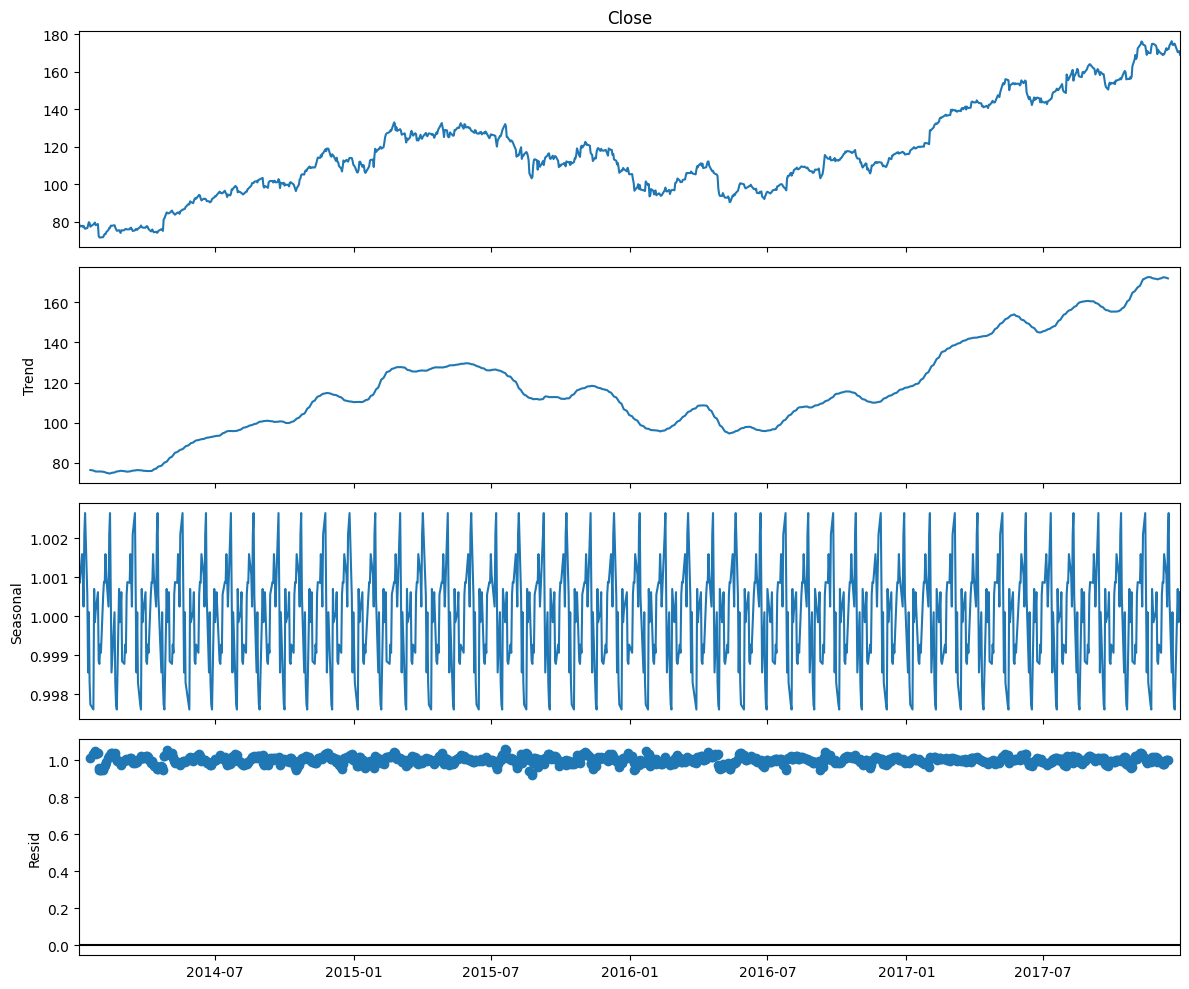

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
result = seasonal_decompose(dp_aapl['Close'], model='multiplicative', period=22)
plt.rc('figure', figsize=(12, 10))
result.plot()
plt.savefig('seasonal_decompose_plot.png')
plt.show()

In [ ]:
dp_aapl['50_day_MA'] = dp_aapl['Close'].rolling(window=50).mean()
dp_aapl['200_day_MA'] = dp_aapl['Close'].rolling(window=200).mean()
print('DataFrame with 50-day and 200-day Moving Averages:')
display(dp_aapl.head())

DataFrame with 50-day and 200-day Moving Averages:


,Symbol,Open,High,Low,Close,Volume,50_day_MA,200_day_MA,Target
Date,,,,,,,,,
2014-10-16,AAPL,95.550,97.72,95.41,96.26,72154523,NaN,NaN,1
2014-10-17,AAPL,97.500,99.00,96.81,97.67,68179688,NaN,NaN,1
2014-10-20,AAPL,98.315,99.96,98.22,99.76,77517279,NaN,NaN,1
2014-10-21,AAPL,103.020,103.02,101.27,102.47,94623904,NaN,NaN,1
2014-10-22,AAPL,102.840,104.11,102.60,102.99,68263146,NaN,NaN,1


In [ ]:
numerical_features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[numerical_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled data shape:', X_scaled.shape)
print('First 5 rows of scaled data:\n', X_scaled[:5])

Scaled data shape: (497472, 5)
First 5 rows of scaled data:
 [[-0.60393836 -0.5992692  -0.60148948 -0.60123875  0.57644031]
 [-0.06868051 -0.07385684 -0.06653859 -0.07243929  6.62505812]
 [ 0.23660277  0.24188945  0.23603523  0.23031819 -0.45078242]
 [-0.33735802 -0.34015793 -0.33838959 -0.33890116  0.03831937]
 [-0.16006484 -0.16520162 -0.1598078  -0.1623998  -0.3772073 ]]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])

print('PCA transformed data shape:', df_pca.shape)
print('First 5 rows of PCA transformed data:\n', df_pca.head())

PCA transformed data shape: (497472, 2)
First 5 rows of PCA transformed data:
    principal_component_1  principal_component_2
0              -1.253567               0.456056
1              -0.787864               6.579545
2               0.514235              -0.402427
3              -0.677904              -0.028100
4              -0.285303              -0.407056


In [ ]:
from sklearn.cluster import KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_pca['cluster'] = kmeans.fit_predict(X_pca)

print(f'Number of data points per cluster:\n{df_pca["cluster"].value_counts()}')
print('\nFirst 5 rows of PCA transformed data with cluster labels:\n', df_pca.head())

Number of data points per cluster:
cluster
0    404781
2     87257
1      5434
Name: count, dtype: int64

First 5 rows of PCA transformed data with cluster labels:
    principal_component_1  principal_component_2  cluster
0              -1.253567               0.456056        0
1              -0.787864               6.579545        0
2               0.514235              -0.402427        0
3              -0.677904              -0.028100        0
4              -0.285303              -0.407056        0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='cluster', data=df_pca, palette='viridis', s=100, alpha=0.7)
plt.title('K-Means Clustering of Stock Data (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.savefig('kmeans_clustering_pca.png')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dp_aapl['Target'] = (dp_aapl['Close'].shift(-1) > dp_aapl['Close']).astype(int)
dp_aapl.dropna(inplace=True)

X = dp_aapl[['Open','High','Low','Close','Volume']]
y = dp_aapl['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data split and scaled successfully.')

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('\nClassification Report:')
print(report)
print('\nConfusion Matrix:')
print(conf_matrix)
print('\nRandomForestClassifier model trained and evaluated successfully.')

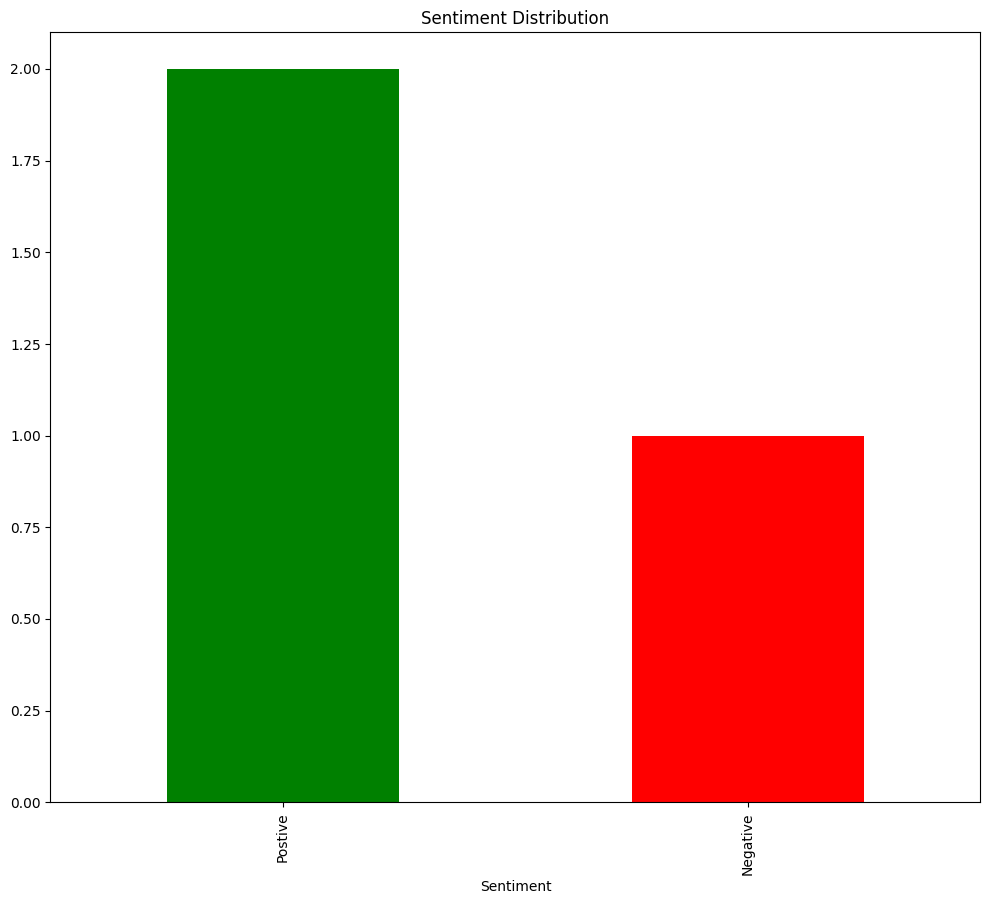

In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import pandas as pd
data = {'Review':[
  'Iam very optimistic about the future with tech',
  'Poor customer service',
  'Product fast and reliable'
]}
df_nlp = pd.DataFrame(data)
def get_sentiment(text):
  score = TextBlob(text).sentiment.polarity
  if score>0:return 'Postive'
  elif score<0:return 'Negative'
  else:return 'Neutral'
df_nlp['Sentiment'] = df_nlp['Review'].apply(get_sentiment)
df_nlp['Sentiment'].value_counts().plot(kind='bar',color=['green','red','gray'])
plt.title('Sentiment Distribution')
plt.savefig('sentiment_distribution.png')
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
all_words =''.join(df_nlp['Review'])
wordcloud = WordCloud(width =800,height=400,background_color='white').generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud.png')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2,
                           scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best cross-validation accuracy: {grid_search.best_score_:.2f}')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best parameters found: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation accuracy: 0.54


In [ ]:

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f'Accuracy of best model: {accuracy_tuned:.2f}')
print('\nClassification Report of best model:')
print(report_tuned)
print('\nConfusion Matrix of best model:')
print(conf_matrix_tuned)
print('\nHyperparameter tuning complete and best model evaluated.')

Accuracy of best model: 0.52

Classification Report of best model:
              precision    recall  f1-score   support

           0       0.54      0.45      0.49        84
           1       0.50      0.59      0.54        78

    accuracy                           0.52       162
   macro avg       0.52      0.52      0.52       162
weighted avg       0.52      0.52      0.52       162


Confusion Matrix of best model:
[[38 46]
 [32 46]]

Hyperparameter tuning complete and best model evaluated.


In [ ]:
from google.colab import files
df_nlp.to_csv('cleaned_data_for_csv.csv', index=False)
files.download('cleaned_data_for_csv.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>